# DIV2K Dataset

High resolution and their downsampled version. With $2x$ downsampling the downsampled image has half the definition of the HR image. Not all images have the same resolution.

In [12]:
from PIL import Image
for i in range(1, 9):
    hr = Image.open("data/DIV2K_valid_HR/080"+str(i)+".png")
    lr = Image.open("data/DIV2K_valid_LR_bicubic/X2/080"+str(i)+"x2.png")
    print(hr.size, lr.size)  # verify the 2× ratio

(2040, 1356) (1020, 678)
(2040, 1356) (1020, 678)
(2040, 1536) (1020, 768)
(2040, 1200) (1020, 600)
(2040, 1536) (1020, 768)
(2040, 1356) (1020, 678)
(2040, 1128) (1020, 564)
(2040, 1356) (1020, 678)


In [33]:
from Model.super_res_dataset import *
import matplotlib.pyplot as plt

HR_DIR = 'data/DIV2K_valid_HR/'
LR_DIR = 'data/DIV2K_valid_LR_bicubic/X2/'
HR_PATCH = 128
SCALE = 2
SEED = 42
N_EVAL_IMGS = 16

eval_ds = DIV2KDataset(HR_DIR, LR_DIR, hr_patch_size=HR_PATCH, scale=SCALE, seed=SEED)
fixed_lr, fixed_hr, _ = next(iter(DataLoader(eval_ds, batch_size=N_EVAL_IMGS)))

In [34]:
import numpy as np
def denorm(t: torch.Tensor) -> np.ndarray:
    """[-1,1] tensor (3,H,W) → uint8 numpy (H,W,3) for imshow."""
    t = (t * 0.5 + 0.5).clamp(0, 1)
    return (t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)


In [35]:
hr_img.shape

(128, 128, 3)

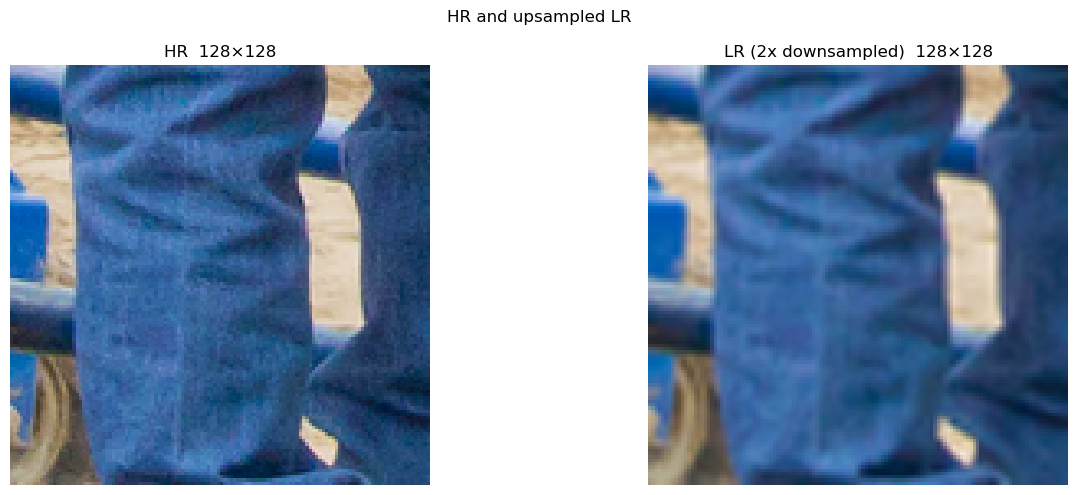

In [40]:
hr_img = denorm(fixed_hr[3])
lr_img = denorm(fixed_lr[3])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(hr_img)
axes[0].set_title(f"HR  {hr_img.shape[0]}×{hr_img.shape[1]}")
axes[0].axis("off")
axes[1].imshow(lr_img)
axes[1].set_title(f"LR (2x downsampled)  {lr_img.shape[0]}×{lr_img.shape[1]}")
axes[1].axis("off")
plt.suptitle("HR and upsampled LR")
plt.tight_layout()